In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pickle
import time
import random
from random import shuffle
import sys
from naval_models import *
sys.path.append("..")
from neurons import *

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
random.seed(42)
with open('naval_dataset.pkl', 'rb') as f:
    train_data, train_label, val_data, val_label = pickle.load(f)

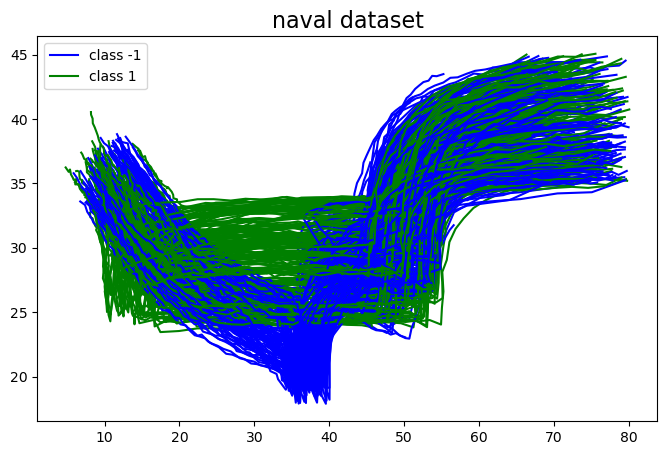

In [3]:
plt.figure(figsize=(8, 5))
for i in range(val_data.shape[0]):
    if val_label[i] == 1:
        plt.plot(val_data[i,:,0],val_data[i,:,1],color='g',label='class 1')
    else:
        plt.plot(val_data[i,:,0],val_data[i,:,1],color='b',label='class -1')
handles, labels_legend = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels_legend, handles))
plt.legend(by_label.values(), by_label.keys())
plt.title("naval dataset", fontsize=16)
plt.show()

epoch =  50, loss_inf = 0.04, training network accuracy = 0.97, training formula accuracy = 0.92
validation network accuracy = 0.96, validation formula accuracy = 0.92
epoch = 100, loss_inf = 0.04, training network accuracy = 0.96, training formula accuracy = 0.65
validation network accuracy = 0.96, validation formula accuracy = 0.67
epoch = 150, loss_inf = 0.04, training network accuracy = 0.99, training formula accuracy = 0.74
validation network accuracy = 0.99, validation formula accuracy = 0.75
epoch = 200, loss_inf = 0.02, training network accuracy = 0.99, training formula accuracy = 0.74
validation network accuracy = 0.98, validation formula accuracy = 0.74
epoch = 250, loss_inf = 0.01, training network accuracy = 1.00, training formula accuracy = 1.00
validation network accuracy = 1.00, validation formula accuracy = 1.00
epoch = 300, loss_inf = 0.01, training network accuracy = 1.00, training formula accuracy = 1.00
validation network accuracy = 1.00, validation formula accuracy

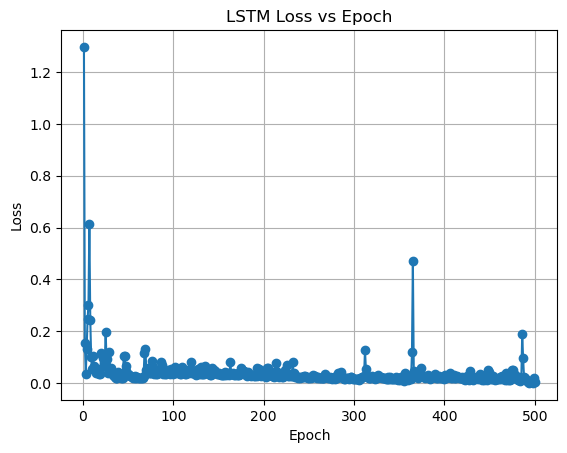

In [8]:
dataset = CustomDataset(train_data, train_label)
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
nsample = train_data.shape[0]
val_nsample = val_data.shape[0]
length = train_data.shape[1]
dim = train_data.shape[2]
nf = dim*3
nc = 1
weight_bi = [1e-0,1e-0,1e-0] # weight for bi-modal regularizer
weight_l1 = [1e-2] # weight for L1 regularizer
weight_margin = 1e-2 # weight for margin

# initialize
epochs_inf = 500
relu = torch.nn.ReLU()
stl = NavalModel1(nf,nc,length,weight_bi,weight_l1)
stl_optimizer = torch.optim.Adam(stl.parameters(), lr=1e-1)

train_losses = {}
stl.train()
total_time = 0
acc_best = 0
for epoch in range(epochs_inf):
    epoch_losses = list()
    for batch_idx, (data_batch, labels_batch) in enumerate(dataloader):
        start_time = time.time()
        stl_optimizer.zero_grad()
        r, reg = stl(data_batch)
        loss_inf = torch.mean(relu(stl.eps-labels_batch*r)) - weight_margin*stl.eps + reg
        loss_inf.backward()
        stl_optimizer.step()
        end_time = time.time()
        total_time += end_time - start_time
        
        epoch_losses.append(loss_inf.detach().item())

    train_losses[epoch] = torch.tensor(epoch_losses).mean()
    loss_log = list(train_losses.values())
    loss_log = [x.item() for x in loss_log]

    if (epoch+1) % 10 == 0:
        with torch.no_grad():
            r_train, _,  = stl(train_data)
            r_train = Clip.apply(r_train)
            acc_train = torch.sum((r_train==train_label))/nsample
            accf_train = stl.accuracy_formula(train_data, train_label)
            r_val, _,  = stl(val_data)
            r_val = Clip.apply(r_val)
            acc = torch.sum((r_val==val_label))/val_nsample
            accf = stl.accuracy_formula(val_data, val_label)
        if accf_train>=acc_best:
            acc_best = accf_train
            torch.save(stl.state_dict(), f'naval_TLINet1.pth')
    if (epoch+1) % 50 == 0:
        print('epoch = {:3d}, loss_inf = {:.2f}, training network accuracy = {:.2f}, training formula accuracy = {:.2f}'.format(epoch+1,loss_inf,acc_train,accf_train))
        print('validation network accuracy = {:.2f}, validation formula accuracy = {:.2f}'.format(acc,accf))
    stl_optimizer.zero_grad()
print('Total training time is {:.2f}'.format(total_time))
print('Best training formula accuracy is {:.2f}'.format(acc_best))
plt.plot(range(1, epochs_inf+1), loss_log, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Loss vs Epoch')
plt.grid()
plt.show()

In [3]:
with torch.no_grad():
    stl.load_state_dict(torch.load('naval_TLINet1.pth', weights_only=True))
    stl.translate_formula()

G[0,16]y>23.80
 ∧ 
F[54,59]x<31.27


epoch =  50, loss_inf = 0.02, training network accuracy = 0.99, training formula accuracy = 0.75
validation network accuracy = 1.00, validation formula accuracy = 0.76
epoch = 100, loss_inf = 0.00, training network accuracy = 0.99, training formula accuracy = 0.93
validation network accuracy = 1.00, validation formula accuracy = 0.94
epoch = 150, loss_inf = 0.00, training network accuracy = 0.98, training formula accuracy = 0.75
validation network accuracy = 0.99, validation formula accuracy = 0.75
epoch = 200, loss_inf = 0.00, training network accuracy = 1.00, training formula accuracy = 1.00
validation network accuracy = 1.00, validation formula accuracy = 1.00
epoch = 250, loss_inf = 0.00, training network accuracy = 1.00, training formula accuracy = 1.00
validation network accuracy = 1.00, validation formula accuracy = 1.00
epoch = 300, loss_inf = 0.04, training network accuracy = 0.89, training formula accuracy = 0.50
validation network accuracy = 0.91, validation formula accuracy

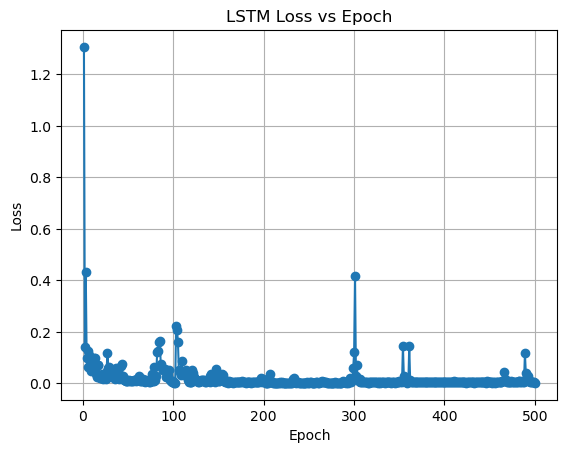

In [12]:
dataset = CustomDataset(train_data, train_label)
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
nsample = train_data.shape[0]
val_nsample = val_data.shape[0]
length = train_data.shape[1]
dim = train_data.shape[2]
nf = dim*3
nc1 = 2
nc2 = 1
weight_bi = [1e-0,1e-0,1e-0,1e-0,1e-0] # weight for bi-modal regularizer
weight_l1 = [1e-4,1e-4] # weight for L1 regularizer
weight_margin = 1e-3 # weight for margin

# initialize
epochs_inf = 500
relu = torch.nn.ReLU()
stl = NavalModel2(nf,nc1,nc2,length,weight_bi,weight_l1)
stl_optimizer = torch.optim.Adam(stl.parameters(), lr=1e-1)

train_losses = {}
stl.train()
total_time = 0
acc_best = 0
for epoch in range(epochs_inf):
    epoch_losses = list()
    for batch_idx, (data_batch, labels_batch) in enumerate(dataloader):
        start_time = time.time()
        stl_optimizer.zero_grad()
        r, reg = stl(data_batch)
        loss_inf = torch.mean(relu(stl.eps-labels_batch*r)) - weight_margin*stl.eps + reg
        loss_inf.backward()
        stl_optimizer.step()
        end_time = time.time()
        total_time += end_time - start_time
        
        epoch_losses.append(loss_inf.detach().item())

    train_losses[epoch] = torch.tensor(epoch_losses).mean()
    loss_log = list(train_losses.values())
    loss_log = [x.item() for x in loss_log]

    if (epoch+1) % 10 == 0:
        with torch.no_grad():
            r_train, _,  = stl(train_data)
            r_train = Clip.apply(r_train)
            acc_train = torch.sum((r_train==train_label))/nsample
            accf_train = stl.accuracy_formula(train_data, train_label)
            r_val, _,  = stl(val_data)
            r_val = Clip.apply(r_val)
            acc = torch.sum((r_val==val_label))/val_nsample
            accf = stl.accuracy_formula(val_data, val_label)
        if accf_train>=acc_best:
            acc_best = accf_train
            torch.save(stl.state_dict(), f'naval_TLINet2.pth')
    if (epoch+1) % 50 == 0:
        print('epoch = {:3d}, loss_inf = {:.2f}, training network accuracy = {:.2f}, training formula accuracy = {:.2f}'.format(epoch+1,loss_inf,acc_train,accf_train))
        print('validation network accuracy = {:.2f}, validation formula accuracy = {:.2f}'.format(acc,accf))
    stl_optimizer.zero_grad()
print('Total training time is {:.2f}'.format(total_time))
print('Best training formula accuracy is {:.2f}'.format(acc_best))
plt.plot(range(1, epochs_inf+1), loss_log, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Loss vs Epoch')
plt.grid()
plt.show()

In [5]:
with torch.no_grad():
    stl.load_state_dict(torch.load('naval_TLINet2.pth', weights_only=True))
    stl.translate_formula()

G[8,15]y>22.60 ∧ G[56,60]x<29.93


epoch =  50, loss_inf = 0.09, training network accuracy = 0.67, training formula accuracy = 0.50
validation network accuracy = 0.67, validation formula accuracy = 0.50
epoch = 100, loss_inf = 0.03, training network accuracy = 0.99, training formula accuracy = 0.50
validation network accuracy = 0.99, validation formula accuracy = 0.50
epoch = 150, loss_inf = 0.03, training network accuracy = 0.91, training formula accuracy = 0.50
validation network accuracy = 0.91, validation formula accuracy = 0.50
epoch = 200, loss_inf = 0.03, training network accuracy = 0.97, training formula accuracy = 0.50
validation network accuracy = 0.97, validation formula accuracy = 0.50
epoch = 250, loss_inf = 0.00, training network accuracy = 0.98, training formula accuracy = 0.50
validation network accuracy = 0.98, validation formula accuracy = 0.50
epoch = 300, loss_inf = 0.11, training network accuracy = 0.91, training formula accuracy = 0.50
validation network accuracy = 0.92, validation formula accuracy

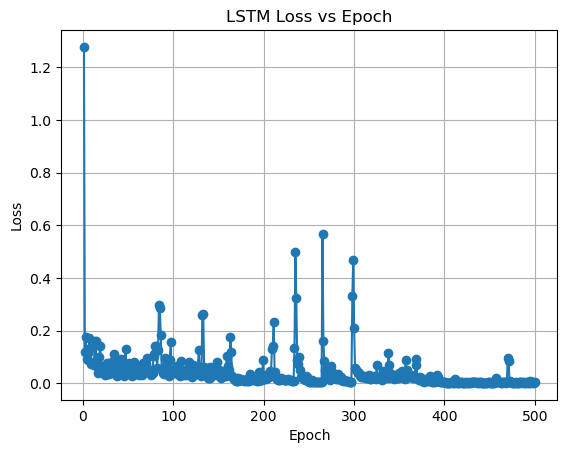

In [6]:
random.seed(6)
dataset = CustomDataset(train_data, train_label)
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
nsample = train_data.shape[0]
val_nsample = val_data.shape[0]
length = train_data.shape[1]
dim = train_data.shape[2]
nf = dim*3
nc1 = 4
nc2 = 1
weight_bi = [1e-0,1e-0,1e-0,1e-0,1e-0] # weight for bi-modal regularizer
weight_l1 = [1e-4,1e-4] # weight for L1 regularizer
weight_margin = 1e-3 # weight for margin

# initialize
epochs_inf = 500
relu = torch.nn.ReLU()
stl = NavalModel3(nf,nc1,nc2,length,weight_bi,weight_l1)
stl_optimizer = torch.optim.Adam(stl.parameters(), lr=1e-1)

train_losses = {}
stl.train()
total_time = 0
acc_best = 0
for epoch in range(epochs_inf):
    epoch_losses = list()
    for batch_idx, (data_batch, labels_batch) in enumerate(dataloader):
        start_time = time.time()
        stl_optimizer.zero_grad()
        r, reg = stl(data_batch)
        loss_inf = torch.mean(relu(stl.eps-labels_batch*r)) - weight_margin*stl.eps + reg
        loss_inf.backward()
        stl_optimizer.step()
        end_time = time.time()
        total_time += end_time - start_time
        
        epoch_losses.append(loss_inf.detach().item())

    train_losses[epoch] = torch.tensor(epoch_losses).mean()
    loss_log = list(train_losses.values())
    loss_log = [x.item() for x in loss_log]

    if (epoch+1) % 10 == 0:
        with torch.no_grad():
            r_train, _,  = stl(train_data)
            r_train = Clip.apply(r_train)
            acc_train = torch.sum((r_train==train_label))/nsample
            accf_train = stl.accuracy_formula(train_data, train_label)
            r_val, _,  = stl(val_data)
            r_val = Clip.apply(r_val)
            acc = torch.sum((r_val==val_label))/val_nsample
            accf = stl.accuracy_formula(val_data, val_label)
        if accf_train>=acc_best:
            acc_best = accf_train
            torch.save(stl.state_dict(), f'naval_TLINet3.pth')
    if (epoch+1) % 50 == 0:
        print('epoch = {:3d}, loss_inf = {:.2f}, training network accuracy = {:.2f}, training formula accuracy = {:.2f}'.format(epoch+1,loss_inf,acc_train,accf_train))
        print('validation network accuracy = {:.2f}, validation formula accuracy = {:.2f}'.format(acc,accf))
    stl_optimizer.zero_grad()
print('Total training time is {:.2f}'.format(total_time))
print('Best training formula accuracy is {:.2f}'.format(acc_best))
plt.plot(range(1, epochs_inf+1), loss_log, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Loss vs Epoch')
plt.grid()
plt.show()

In [6]:
with torch.no_grad():
    stl.load_state_dict(torch.load('naval_TLINet3.pth', weights_only=True))
    stl.translate_formula()

F[51,59]x<27.92
 ∧ 
G[10,15]y>22.23


epoch =  50, loss_inf = 0.00, validation accuracy = 1.00
epoch = 100, loss_inf = 0.00, validation accuracy = 1.00
epoch = 150, loss_inf = 0.00, validation accuracy = 1.00
epoch = 200, loss_inf = 0.00, validation accuracy = 1.00
epoch = 250, loss_inf = 0.00, validation accuracy = 1.00
epoch = 300, loss_inf = 0.00, validation accuracy = 1.00
epoch = 350, loss_inf = 0.00, validation accuracy = 1.00
epoch = 400, loss_inf = 0.00, validation accuracy = 1.00
epoch = 450, loss_inf = 0.00, validation accuracy = 1.00
epoch = 500, loss_inf = 0.00, validation accuracy = 1.00
Total training time is 308.15


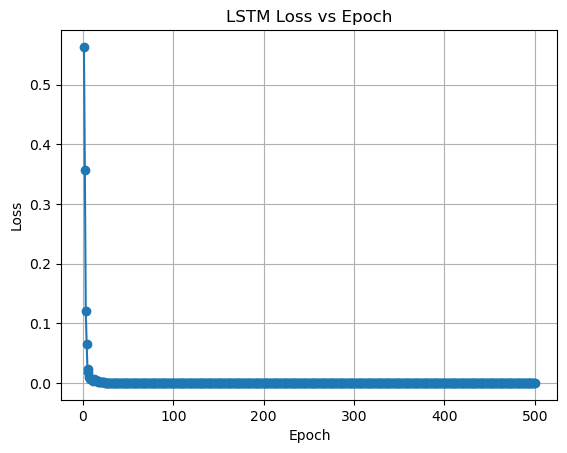

In [20]:
dataset = LSTMDataset(train_data, train_label)
val_label[val_label<0] = 0
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
input_size = train_data.shape[2]
hidden_size = 128
num_layers = 1
output_size = 1
learning_rate = 0.001

model = LSTMModel(input_size, hidden_size, num_layers, output_size)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_losses = {}
epochs_inf = 500
total_time = 0
acc_best = 0
for epoch in range(epochs_inf):
    epoch_losses = list()
    for batch_idx, (data_batch, labels_batch) in enumerate(dataloader):
        model.train()
        optimizer.zero_grad()
        outputs = model(data_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.detach().item())

    train_losses[epoch] = torch.tensor(epoch_losses).mean()
    loss_log = list(train_losses.values())
    loss_log = [x.item() for x in loss_log]

    if (epoch+1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_outputs = model(val_data)
            threshold = 0.5 
            binary_predictions = (np.array(val_outputs)>threshold).astype(float)
            val_acc = sum(binary_predictions==np.array(val_label))/val_data.shape[0]
            torch.save(model.state_dict(), f'naval_LSTM_model.pth')
    if (epoch+1) % 50 == 0:
        print('epoch = {:3d}, loss_inf = {:.2f}, validation accuracy = {:.2f}'.format(epoch+1,loss,val_acc))
plt.plot(range(1, epochs_inf+1), loss_log, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Loss vs Epoch')
plt.grid()
plt.show()